### APIs and Data Collection

APIs specifically REST APIs allow our programs to communicate through the internet hence we can obtain and 
process data rom multiple sources and storage sources.

HTTP methods are a way of transmitting the data over the internet.

In [5]:
from pycoingecko import CoinGeckoAPI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from nba_api.stats.static import teams
from nba_api.stats.endpoints import leaguegamefinder
import seaborn as sns
import requests
import numpy as np

In [1]:
import requests

filename = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/PY0101EN/Chapter%205/Labs/Golden_State.pkl"

def download(url, filename):
    response = requests.get(url)
    print(response.headers)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)

download(filename, "data/Golden_State.pkl")

{'Date': 'Mon, 14 Sep 2026 06:51:41 GMT', 'X-Clv-Request-Id': 'e260b697-66d3-4efc-90bb-fca3f0656dcd', 'Server': 'Cleversafe', 'X-Clv-S3-Version': '2.5', 'Accept-Ranges': 'bytes', 'x-amz-request-id': 'e260b697-66d3-4efc-90bb-fca3f0656dcd', 'ETag': '"ef533d4196874ecc62c4f24bc249dba4"', 'Content-Type': 'application/octet-stream', 'Last-Modified': 'Mon, 15 Jul 2019 17:51:05 GMT', 'Content-Length': '811065'}


In [6]:
games = pd.read_pickle("data/Golden_State.pkl")
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22019,1610612744,GSW,Golden State Warriors,1521900066,2019-07-12,GSW vs. LAL,L,200,87,...,0.800,13.0,29.0,42.0,13,10.0,3,11.0,21,3.2
1,22019,1610612744,GSW,Golden State Warriors,1521900058,2019-07-10,GSW @ DEN,W,201,73,...,0.867,7.0,27.0,34.0,10,11.0,7,20.0,20,-8.0
2,22019,1610612744,GSW,Golden State Warriors,1521900039,2019-07-08,GSW @ LAL,W,200,88,...,0.621,8.0,29.0,37.0,21,10.0,4,13.0,22,8.0
3,22019,1610612744,GSW,Golden State Warriors,1521900020,2019-07-07,GSW vs. TOR,W,201,80,...,0.923,6.0,37.0,43.0,18,8.0,3,20.0,25,10.0
4,22019,1610612744,GSW,Golden State Warriors,1521900007,2019-07-05,GSW vs. CHA,L,200,85,...,0.889,8.0,28.0,36.0,19,9.0,3,13.0,15,-8.0


In [7]:
games_away = games[games["MATCHUP"]=="GSW @ TOR"]
games_home =  games[games["MATCHUP"]=="GSW vs. TOR"]

In [8]:
print(games_away["PLUS_MINUS"].mean())
print(games_home["PLUS_MINUS"].mean())

-0.6071428571428571
3.730769230769231


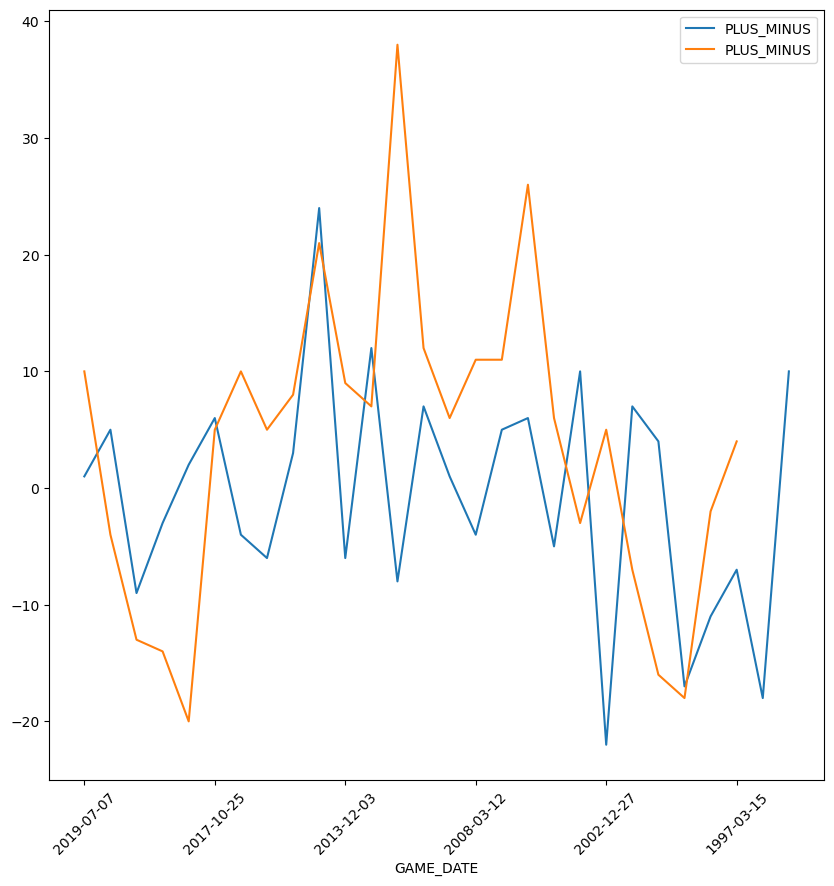

In [9]:
fig, ax = plt.subplots(figsize = (10,10))
games_away.plot(x="GAME_DATE", y="PLUS_MINUS", ax=ax)
games_home.plot(x="GAME_DATE", y="PLUS_MINUS", ax=ax)
ax.tick_params(axis='x', labelrotation=45)

In [10]:
cg = CoinGeckoAPI()
bitcoin_data = cg.get_coin_market_chart_by_id(id='bitcoin', vs_currency='usd', days =30)

In [11]:
type(bitcoin_data)

dict

In [12]:
bitcoin_data.keys()

dict_keys(['prices', 'market_caps', 'total_volumes'])

In [13]:
data = pd.DataFrame(bitcoin_data['prices'], columns=["TimeStamp","Price"])

In [14]:
data["Date"] = pd.to_datetime(data["TimeStamp"],unit='ms')

In [15]:
candlestick_data = data.groupby(data.Date.dt.date).agg({"Price":["min","max","first","last"]})

In [16]:
fig = go.Figure(data = [go.Candlestick(x=candlestick_data.index,
                                                   open=candlestick_data['Price']['first'],
                                                    high = candlestick_data['Price']['max'],
                                                    low = candlestick_data['Price']['min'],
                                                    close = candlestick_data['Price']['last']
                                                   )
                                    ])

fig.update_layout(xaxis_rangeslider_visible=False,
                  xaxis_title='Date', 
                  yaxis_title = 'Price (usd $)',
                  title = 'Bitcoin CandleStick Chart over the past 30 days'
                 )
fig.show()

## HTTP Methods and descriptions

These include: 

GET Retrieves data from the server

POST Submits data to the server

PUT Updates data already on the server

DELETE Deletes data from the server

In [17]:
import os


url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/Example1.txt"
req = requests.get(url)
path = "data/Example.txt"
with open(path,"wb") as file_name:
    file_name.write(req.content)

    

In [18]:
url_get='https://httpbin.org/get'
params = {"name":"Joseph","ID":"123"}
rs = requests.get(url_get, params = params)


In [19]:
print(rs.url)

https://httpbin.org/get?name=Joseph&ID=123


In [20]:
print(rs.request.body) ## There is no request body, body is mostly in POST and UPDATE requests

None


In [21]:
print(rs.headers["content-type"])

application/json


In [22]:
rs.json()

{'args': {'ID': '123', 'name': 'Joseph'},
 'headers': {'Accept': '*/*',
  'Accept-Encoding': 'gzip, deflate, br, zstd',
  'Host': 'httpbin.org',
  'User-Agent': 'python-requests/2.32.5',
  'X-Amzn-Trace-Id': 'Root=1-6aa799cc-164fcd3749f9a57a51c87c8d'},
 'origin': '197.248.18.239',
 'url': 'https://httpbin.org/get?name=Joseph&ID=123'}

In [23]:
rs.json()['args']

{'ID': '123', 'name': 'Joseph'}

### POST Requests

In [24]:
url_post = 'https://httpbin.org/post'
payload = params
r_post = requests.post(url_post, data = payload)


In [25]:
## Check how the URLs are:
print(rs.url)
print(r_post.url)

https://httpbin.org/get?name=Joseph&ID=123
https://httpbin.org/post


In [26]:
## Check how different the request body are
print(rs.request.body)
print(r_post.request.body)

None
name=Joseph&ID=123


In [27]:
r_post.json()

{'args': {},
 'data': '',
 'files': {},
 'form': {'ID': '123', 'name': 'Joseph'},
 'headers': {'Accept': '*/*',
  'Accept-Encoding': 'gzip, deflate, br, zstd',
  'Content-Length': '18',
  'Content-Type': 'application/x-www-form-urlencoded',
  'Host': 'httpbin.org',
  'User-Agent': 'python-requests/2.32.5',
  'X-Amzn-Trace-Id': 'Root=1-6aa799d3-5ab6042d49a97c8f37ca6b80'},
 'json': None,
 'origin': '197.248.18.239',
 'url': 'https://httpbin.org/post'}

In [28]:
print(r_post.json()['form'])

{'ID': '123', 'name': 'Joseph'}


In [29]:
# More APIs to extract data as JSON into a dataframe

jokes_url = "https://official-joke-api.appspot.com/jokes/ten"
res = requests.get(jokes_url)
if res.status_code == 200:
    data = res.json()

In [30]:
df_jokes = pd.json_normalize(data)
df_jokes.drop(columns=["type","id"], inplace=True)
df_jokes

,setup,punchline
0,Why did the functions stop calling each other?,Because they had constant arguments.
1,Did you hear about the bread factory burning d...,They say the business is toast.
2,What's the best thing about a Boolean?,"Even if you're wrong, you're only off by a bit."
3,What do you call a dad that has fallen through...,A Popsicle.
4,Have you heard of the band 1023MB?,They haven't got a gig yet.
5,What's red and bad for your teeth?,A Brick.
6,I can't tell if i like this blender...,It keeps giving me mixed results.
7,How do you make a tissue dance?,You put a little boogie on it.
8,what do you call a dog that can do magic tricks?,a labracadabrador
9,How does a scientist freshen their breath?,With experi-mints!


In [31]:
import json 

data = requests.get("https://web.archive.org/web/20240929211114/https://fruityvice.com/api/fruit/all", timeout=30)
data.raise_for_status()
results = json.loads(data.text)
#df_fruits = pd.DataFrame(results)

In [32]:
df_fruits = pd.json_normalize(results)  ## converts nested JSON data into a dataframe
df_fruits.head()

,name,id,family,order,genus,nutritions.calories,nutritions.fat,nutritions.sugar,nutritions.carbohydrates,nutritions.protein
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,81,0.0,18.0,18.0,0.0
1,Strawberry,3,Rosaceae,Rosales,Fragaria,29,0.4,5.4,5.5,0.8
2,Banana,1,Musaceae,Zingiberales,Musa,96,0.2,17.2,22.0,1.0
3,Tomato,5,Solanaceae,Solanales,Solanum,74,0.2,2.6,3.9,0.9
4,Pear,4,Rosaceae,Rosales,Pyrus,57,0.1,10.0,15.0,0.4


In [34]:
urls_tables = 'https://en.wikipedia.org/wiki/List_of_largest_banks'
#tables = pd.read_html(urls_tables,flavor='bs4')
#df = tables[0]


## Working with different file formats


In [35]:
import json

with open("data/example.json","r") as json_file:
    json_obj = json.load(json_file)


## json.load() we use this to read file objects from the dist
## json.loads() we use this to read JSON str data from memory such as an API response string 

In [36]:
json_obj

{'homer': 'Immortals',
 'Blood Angels': 'Sanguinuis',
 'Ultra Marines': 'Robute Guiliman'}

In [37]:
import xml.etree.ElementTree as etree

In [40]:
#tree = etree.parse("data/basic-structure.xml")
#root = tree.getroot()

In [41]:
import json

In [42]:
person = {
    'first_name' : 'Mark',
    'last_name' : 'abc',
    'age' : 27,
    'address': {
        "streetAddress": "21 2nd Street",
        "city": "New York",
        "state": "NY",
        "postalCode": "10021-3100"
    }
}

In [43]:
print(json.dumps(person, indent=4))

## json.dumps() hands me over a json formatted string in memory

{
    "first_name": "Mark",
    "last_name": "abc",
    "age": 27,
    "address": {
        "streetAddress": "21 2nd Street",
        "city": "New York",
        "state": "NY",
        "postalCode": "10021-3100"
    }
}


In [44]:
with open("data/person.json","w") as json_file:
    json.dump(person, json_file, indent=4)

##### Reading json data

In [45]:
with open("data/person.json",'r') as f:
    person_object = json.load(f)


In [46]:
person_object

{'first_name': 'Mark',
 'last_name': 'abc',
 'age': 27,
 'address': {'streetAddress': '21 2nd Street',
  'city': 'New York',
  'state': 'NY',
  'postalCode': '10021-3100'}}

In [ ]:
fileURL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/file_example_XLSX_10.xlsx"
response = requests.get(fileURL)
with open("data/file.xlsx","wb") as file_name:
    file_name.write((response.content))


In [49]:
pd.read_excel("data/file.xlsx")

,0,First Name,Last Name,Gender,Country,Age,Date,Id
0,1,Dulce,Abril,Female,United States,32,15/10/2017,1562
1,2,Mara,Hashimoto,Female,Great Britain,25,16/08/2016,1582
2,3,Philip,Gent,Male,France,36,21/05/2015,2587
3,4,Kathleen,Hanner,Female,United States,25,15/10/2017,3549
4,5,Nereida,Magwood,Female,United States,58,16/08/2016,2468
5,6,Gaston,Brumm,Male,United States,24,21/05/2015,2554
6,7,Etta,Hurn,Female,Great Britain,56,15/10/2017,3598
7,8,Earlean,Melgar,Female,United States,27,16/08/2016,2456
8,9,Vincenza,Weiland,Female,United States,40,21/05/2015,6548


In [ ]:
import xml.etree.ElementTree as ET

employee = ET.Element('employee')
details = ET.SubElement(employee,'details')
first = ET.SubElement(details,'firstname')
second = ET.SubElement(details,'lastname')
third = ET.SubElement(details,'age')

first.text = 'Shiv'
second.text = 'Roy'
third.text = '26'

mydata1 = ET.ElementTree(employee)

with open("data/samplefile.xml", "wb") as xml_file:
    mydata1.write(xml_file)

#### Reading xml data

We can also read data from a XML file and convert ot into a dataframe.

In [59]:
import xml.etree.ElementTree as etree
import os
from pathlib import Path

file_path = Path("data/sample_employee.xml")

xmlURL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/Sample-employee-XML-file.xml"
res_x = requests.get(xmlURL)

file_path.touch(exist_ok=True)
if res_x.status_code == 200:
    with open(file_path,"wb") as f:
        f.write(res_x.content)

In [ ]:
tree = etree.parse(file_path)
root = tree.getroot()
columns = ["firstname","lastname","title","division","building","room"]
rows = []

for node in root:
    rows.append([node.find(col).text for col in columns])

df_x = pd.DataFrame(rows, columns = columns) ## create a dataframe here
df_x

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,02
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


#### We can also read xml data/file using pandas.read_cml function

In [88]:
df = pd.read_xml("data/sample_employee.xml",xpath="/employees/details")


In [89]:
df

,firstname,lastname,title,division,building,room
0,Shiv,Mishra,Engineer,Computer,301,11
1,Yuh,Datta,developer,Computer,303,2
2,Rahil,Khan,Tester,Computer,304,10
3,Deep,Parekh,Designer,Computer,305,14


| Data Format |      Read          |       Save                            |
--------------|--------------------|---------------------------------------|
|   csv       |  pd.read_csv()     |      df.to_csv(file)                  |
|   json      |  pd.read_json()    |      df.to_json()                     |
|   hdf       |  pd.read_hdf()     |      df.to_hdf()                      |
|   sql       |  pd.read_sql()     |      df.to_sql(query, connection)     |
|   excel     |  pd.read_excel()   |      df.to_excel()                    |

#### Binary file formats

from importlib.metadata import files


Binary files are any files where the format is made of characters that are not directly readable by humans in their raw format.

The file must be run or opened using specialized software first.

Examples include: JPEGS, mp3, mp4, GIFs, binary documents such as word, PDF files

In [91]:
from PIL import Image

def download_image(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as binary_file:
            binary_file.write(response.content)

url = "https://hips.hearstapps.com/hmg-prod.s3.amazonaws.com/images/dog-puppy-on-garden-royalty-free-image-1586966191.jpg"

download_image(url, "data/dog.jpg")

In [93]:
img = Image.open("data/dog.jpg","r")
img.show()

/usr/bin/eog: symbol lookup error: /snap/core20/current/lib/x86_64-linux-gnu/libpthread.so.0: undefined symbol: __libc_pthread_init, version GLIBC_PRIVATE


In [94]:
import pandas as pd

In [115]:
csv_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/diabetes.csv"

csvResponse = requests.get(csv_URL)
if csvResponse.status_code == 200:
    with open("data/diabetes.csv","wb") as file_name:
        file_name.write(csvResponse.content)



b'Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome\n6,148,72,35,0,33.6,0.627,50,1\n1,85,66,29,0,26.6,0.351,31,0\n8,183,64,0,0,23.3,0.672,32,1\n1,89,66,23,94,28.1,0.167,21,0\n0,137,40,35,168,43.1,2.288,33,1\n5,116,74,0,0,25.6,0.201,30,0\n3,78,50,32,88,31,0.248,26,1\n10,115,0,0,0,35.3,0.134,29,0\n2,197,70,45,543,30.5,0.158,53,1\n8,125,96,0,0,0,0.232,54,1\n4,110,92,0,0,37.6,0.191,30,0\n10,168,74,0,0,38,0.537,34,1\n10,139,80,0,0,27.1,1.441,57,0\n1,189,60,23,846,30.1,0.398,59,1\n5,166,72,19,175,25.8,0.587,51,1\n7,100,0,0,0,30,0.484,32,1\n0,118,84,47,230,45.8,0.551,31,1\n7,107,74,0,0,29.6,0.254,31,1\n1,103,30,38,83,43.3,0.183,33,0\n1,115,70,30,96,34.6,0.529,32,1\n3,126,88,41,235,39.3,0.704,27,0\n8,99,84,0,0,35.4,0.388,50,0\n7,196,90,0,0,39.8,0.451,41,1\n9,119,80,35,0,29,0.263,29,1\n11,143,94,33,146,36.6,0.254,51,1\n10,125,70,26,115,31.1,0.205,41,1\n7,147,76,0,0,39.4,0.257,43,1\n1,97,66,15,140,23.2,0.487,22,0\n13,145,82,19,110,22.2,0.245,57,0\n5

In [116]:
df_diabetes = pd.read_csv("data/diabetes.csv")
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [121]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [122]:
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [127]:
for column in df_diabetes.isnull().columns.values.tolist():
    print(column)
    print(df_diabetes.isnull()[column].value_counts())

Pregnancies
Pregnancies
False    768
Name: count, dtype: int64
Glucose
Glucose
False    768
Name: count, dtype: int64
BloodPressure
BloodPressure
False    768
Name: count, dtype: int64
SkinThickness
SkinThickness
False    768
Name: count, dtype: int64
Insulin
Insulin
False    768
Name: count, dtype: int64
BMI
BMI
False    768
Name: count, dtype: int64
DiabetesPedigreeFunction
DiabetesPedigreeFunction
False    768
Name: count, dtype: int64
Age
Age
False    768
Name: count, dtype: int64
Outcome
Outcome
False    768
Name: count, dtype: int64


In [ ]:
df_diabetes['Glucose'] =  df_diabetes['Glucose'].astype('float64')
df_diabetes.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

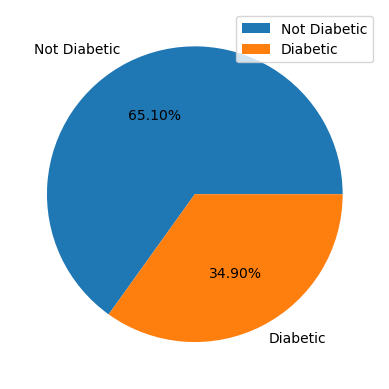

In [134]:
import matplotlib.pyplot as plt
labels = 'Not Diabetic','Diabetic'

#fig, ax  = plt.subplots(figsize=(10,8))
plt.pie(df_diabetes['Outcome'].value_counts(), labels = labels, autopct='%0.02f%%')
plt.legend()
plt.show()

In [ ]:
from socket import SOL_IP

from bs4 import BeautifulSoup
headers = {"User-Agent":"Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/152.0.0.0 Safari/537.36"}

url = "https://en.wikipedia.org/wiki/IBM"

response = requests.get(url, headers=headers)

html_content = response.text

soup = BeautifulSoup(html_content, 'html.parser')

print(type(html_content))

In [35]:
links = soup.find_all('a')
for link in links:
    print(link.text)

Jump to content
Main page
Contents
Current events
Random article
About Wikipedia
Contact us
Help
Learn to edit
Community portal
Recent changes
Upload file
Special pages








Search

Donate
Create account
Log in

Donate

Create account

Log in

(Top)



1
History




1.1
1910s–1950s




1.1.1
World War II




1.2
1960s–1980s




1.3
1990s–2000s




1.4
2010s–present




2
Corporate affairs




2.1
Business trends




2.2
Board and shareholders




2.3
Headquarters and offices




3
Products




3.1
Hardware




3.1.1
Mainframe computers




3.1.2
Microprocessors




3.1.3
Quantum computing




3.2
Software




3.3
Cloud services




3.4
Artificial intelligence




3.5
Consulting




4
Research




4.1
Patents




5
Brand and reputation




6
People and culture




6.1
Employees




6.1.1
Notable current and former employees




6.2
Workplace culture




7
Leadership




7.1
President




7.2
Chairman of the Board




8
See also




9
Notes




10
References




11
Further reading





### Custom data extraction

Web scraping allows you to navigate the HTML structure and extract specific information based on your requirements. 

This process may involve finding specific tags, attributes, or text content within the HTML document.

### Using BeautifulSoup for HTML parsing

Beautiful Soup is a powerful tool for navigating and extracting specific web page parts. 

It allows you to find elements based on their tags, attributes, or text, making extracting the information you're interested in easier.

### Using pandas read_html for table extraction

Pandas, a Python library, provides a function called read_html, which can automatically extract data from websites' tables and present it in a format suitable for analysis. 

It’s similar to taking a table from a webpage and importing it into a spreadsheet for further analysis.